In [198]:
from scipy.io import loadmat
from matplotlib import gridspec
from scipy.stats import linregress
import os
from pyproj import Proj, Transformer
from scipy.spatial.kdtree import KDTree
import pandas as pd
import numpy as np
np.float = float
import datetime
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import warnings
warnings.filterwarnings("ignore")

In [199]:
def lonlat_to_xy(coords_1, coords_2, hemisphere, inverse=False):

    """Converts between longitude/latitude and EASE xy coordinates.
 
    Args:
        lon (float): WGS84 longitude
        lat (float): WGS84 latitude
        hemisphere (string): 'n' or 's'
        inverse (bool): if true, converts xy to lon/lat
 
    Returns:
        tuple: pair of xy or lon/lat values
    """

    EASE_Proj = {'n': 'EPSG:3408',
                 's': 'EPGS:3409'}
    
    WGS_Proj = 'EPSG:4326'
    
    for coords in [coords_1, coords_2]: assert isinstance(coords,(np.ndarray,list))

    if inverse == False: # lonlat to xy
        
        lon, lat = coords_1, coords_2
        
        transformer = Transformer.from_crs(WGS_Proj, EASE_Proj[hemisphere])
        
        x, y = transformer.transform(lat, lon)
        
        return (x, y)

    else: # xy to lonlat
        
        x, y = coords_1, coords_2
        
        transformer = Transformer.from_crs(EASE_Proj[hemisphere], WGS_Proj)
        
        lat, lon = transformer.transform(x, y)
        
        return (lon, lat)

### load mooring data and locate on EASE grid

In [200]:
# load ease lons,lats:
ease_lats = np.load('/Users/carmennab/Dropbox/pb_new/auxiliary/lat_cent.npy')
ease_lons = np.load('/Users/carmennab/Dropbox/pb_new/auxiliary/lon_cent.npy')

# convert into x,y:
ease_x, ease_y = lonlat_to_xy(ease_lons,ease_lats,hemisphere='n')

# create KDTree to find EASE grid cell closest to buoy:
tree = KDTree(list(zip(ease_x.ravel(),ease_y.ravel())))

In [201]:
excel_file = '/Users/carmennab/Dropbox/pb_new/data/ice_draft/mooring positions.xlsx'
locs = pd.read_excel(excel_file)
locs

,Mooring position,LAT (N) DD MM.SS,LON (W) DD MM.SS,lat,lon,ease_lon,ease_lat,start date,end date,combined name
0,NE03 2016-2017,57º 49.8',090º 52.9',57.818889,-90.869167,-90.850981,57.785247,2016-09-30,2017-10-29,NE03
1,NE03 2017-2018,57º 49.776’,090º 52.817’,58.032222,-91.093611,-91.265006,58.014830,2017-10-31,2018-06-26,NE03
2,AN01 2016-2017,59º 58.2',091º 57.1',59.967222,-91.950278,-91.773862,59.874736,2016-09-29,2017-10-31,CMO-A
3,AN01 2017-2018,59º 58.443’,091º 57.236’,60.089722,-92.015556,-92.222878,60.099240,2017-11-02,2018-06-29,CMO-A
4,JB02 2016-2018,54º 40.973’,080º 11.226’,54.936944,-80.246111,-80.292091,54.923508,2016-10-03,2018-05-14,JB02
5,CMO-A 2018-2019,59º 58.610’,091º 56.422’,60.136111,-92.050556,-92.222878,60.099240,2018-06-30,2019-09-21,CMO-A
6,CMO-B 2018-2019,61º 45.613’,084º 18.172’,61.920278,-84.347778,-84.491587,61.847156,2018-06-18,2019-09-24,CMO-B
7,CMO-C 2018-2019,63º 11.001’,081º 58.873’,63.183611,-82.209167,-82.286831,63.120357,2018-06-07,2019-09-24,CMO-C
8,CMO-A 2019-2020,59° 58.782’,91°56.268’,60.183889,-92.007778,-91.787353,60.107382,2019-09-23,2020-09-20,CMO-A
9,CMO-B 2019-2020,61° 45.591’,84°18.347’,61.914167,-84.396389,-84.491587,61.847156,2019-09-25,2020-09-19,CMO-B


In [202]:
locs['ease_lat'] = np.full(len(locs['lat']),np.nan)
locs['ease_lon'] = np.full(len(locs['lon']),np.nan)

In [203]:
datapath = '/Users/carmennab/Dropbox/pb_new/data/ice_draft/Daily_PDFs/'

files = os.listdir(datapath)

start = datetime.date(1,1,1)

all_sits = []

for file in files:
    if file[-3:] == 'mat':
        data = loadmat(f'{datapath}{file}')
        
        y = np.array(data['PDF'][0,0][1][0])

        times = np.array(data['PDF'][0,0][0][0]) 
        
        dates = [(start + datetime.timedelta(t-365)) for t in times]

        means = []
        for count,date in enumerate(dates):
            z = np.array(data['PDF'][0,0][2][:,count])

            mean = (y*z).sum()
            means.append(-mean/0.89)
        
        means = np.array(means)
        means[means<0]=np.nan
        
        lat = locs[locs['Mooring position']==file[:-15]]['lat'].iloc[0]
        lon = locs[locs['Mooring position']==file[:-15]]['lon'].iloc[0]
        
        draft_x,draft_y = lonlat_to_xy(np.array(lon),np.array(lat),hemisphere='n') 

        draft_ease = []

        dist, ind = tree.query([draft_x,draft_y])

        ind2d = np.unravel_index(ind, (ease_lats.shape[0],ease_lats.shape[1]))
        
        ease_lon = ease_lons[ind2d] ; ease_lat = ease_lats[ind2d] 

        locs['ease_lon'][locs['Mooring position']==file[:-15]] = ease_lon
        locs['ease_lat'][locs['Mooring position']==file[:-15]] = ease_lat
        
        for sit, date in zip(means,dates):
            all_sits.append({'mooring':file[:-15],'date':date,'mooring_sit':sit/100,'ease_lon':ease_lon,
                             'ease_lat':ease_lat,'ind2d':ind2d})
        
locs.to_excel(excel_file, index=False) 
all_sits = pd.DataFrame(all_sits).dropna()

In [204]:
new_names = np.array([name.split(' ')[0] for name in all_sits['mooring']])
new_names[new_names == 'AN01'] = 'CMO-A'

all_sits['combined name'] = new_names

In [205]:
all_sits

,mooring,date,mooring_sit,ease_lon,ease_lat,ind2d,combined name
0,AN01 2016-2017,2016-09-29,0.010449,-91.773862,59.874736,"(65, 52)",CMO-A
1,AN01 2016-2017,2016-09-30,0.012600,-91.773862,59.874736,"(65, 52)",CMO-A
2,AN01 2016-2017,2016-10-01,0.011503,-91.773862,59.874736,"(65, 52)",CMO-A
3,AN01 2016-2017,2016-10-02,0.011506,-91.773862,59.874736,"(65, 52)",CMO-A
4,AN01 2016-2017,2016-10-03,0.011212,-91.773862,59.874736,"(65, 52)",CMO-A
...,...,...,...,...,...,...,...
4688,CMO-B 2019-2020,2020-09-15,0.011285,-84.491587,61.847156,"(49, 61)",CMO-B
4689,CMO-B 2019-2020,2020-09-16,0.011203,-84.491587,61.847156,"(49, 61)",CMO-B
4690,CMO-B 2019-2020,2020-09-17,0.011320,-84.491587,61.847156,"(49, 61)",CMO-B
4691,CMO-B 2019-2020,2020-09-18,0.016041,-84.491587,61.847156,"(49, 61)",CMO-B


In [206]:
locs['start date'] = np.full(len(locs),np.nan); locs['end date'] = np.full(len(locs),np.nan)

datapath = '/Users/carmennab/Dropbox/pb_new/data/ice_draft/Daily_PDFs/'

files = os.listdir(datapath)

start = datetime.date(1,1,1)

for file in files:
    if file[-3:] == 'mat':
        data = loadmat(f'{datapath}{file}')

        times = np.array(data['PDF'][0,0][0][0]) 
        
        dates = [(start + datetime.timedelta(t-365)) for t in times]
        
        name = file[:-15]
        
        locs['start date'][locs['Mooring position']==name] = dates[0]
        locs['end date'][locs['Mooring position']==name] = dates[-1]

In [207]:
### combine moorings in same locations
new_names = np.array([name.split(' ')[0] for name in locs['Mooring position']])
new_names[new_names == 'AN01'] = 'CMO-A'

locs['combined name'] = new_names
locs

,Mooring position,LAT (N) DD MM.SS,LON (W) DD MM.SS,lat,lon,ease_lon,ease_lat,start date,end date,combined name
0,NE03 2016-2017,57º 49.8',090º 52.9',57.818889,-90.869167,-90.850981,57.785247,2016-09-30,2017-10-29,NE03
1,NE03 2017-2018,57º 49.776’,090º 52.817’,58.032222,-91.093611,-91.265006,58.014830,2017-10-31,2018-06-26,NE03
2,AN01 2016-2017,59º 58.2',091º 57.1',59.967222,-91.950278,-91.773862,59.874736,2016-09-29,2017-10-31,CMO-A
3,AN01 2017-2018,59º 58.443’,091º 57.236’,60.089722,-92.015556,-92.222878,60.099240,2017-11-02,2018-06-29,CMO-A
4,JB02 2016-2018,54º 40.973’,080º 11.226’,54.936944,-80.246111,-80.292091,54.923508,2016-10-03,2018-05-14,JB02
5,CMO-A 2018-2019,59º 58.610’,091º 56.422’,60.136111,-92.050556,-92.222878,60.099240,2018-06-30,2019-09-21,CMO-A
6,CMO-B 2018-2019,61º 45.613’,084º 18.172’,61.920278,-84.347778,-84.491587,61.847156,2018-06-18,2019-09-24,CMO-B
7,CMO-C 2018-2019,63º 11.001’,081º 58.873’,63.183611,-82.209167,-82.286831,63.120357,2018-06-07,2019-09-24,CMO-C
8,CMO-A 2019-2020,59° 58.782’,91°56.268’,60.183889,-92.007778,-91.787353,60.107382,2019-09-23,2020-09-20,CMO-A
9,CMO-B 2019-2020,61° 45.591’,84°18.347’,61.914167,-84.396389,-84.491587,61.847156,2019-09-25,2020-09-19,CMO-B


### load CS2 sits

In [208]:
datapath = '/Users/carmennab/Dropbox/pb_new/data/SIT/CS2SMOS/'

sits = []
for date,ind2d in zip(all_sits['date'],all_sits['ind2d']):
    str_date = date.strftime('%Y%m%d')
    filepath = f'{datapath}{date.year}/{str_date}.nc'
    if os.path.exists(filepath) == True:
        sit = np.array(Dataset(filepath)['sea_ice_thickness'])[ind2d]
    else:
        sit = np.nan

    sits.append(sit)

all_sits[f'CS2_SIT'] = sits
all_sits = all_sits.dropna()

### plot map and timeseries

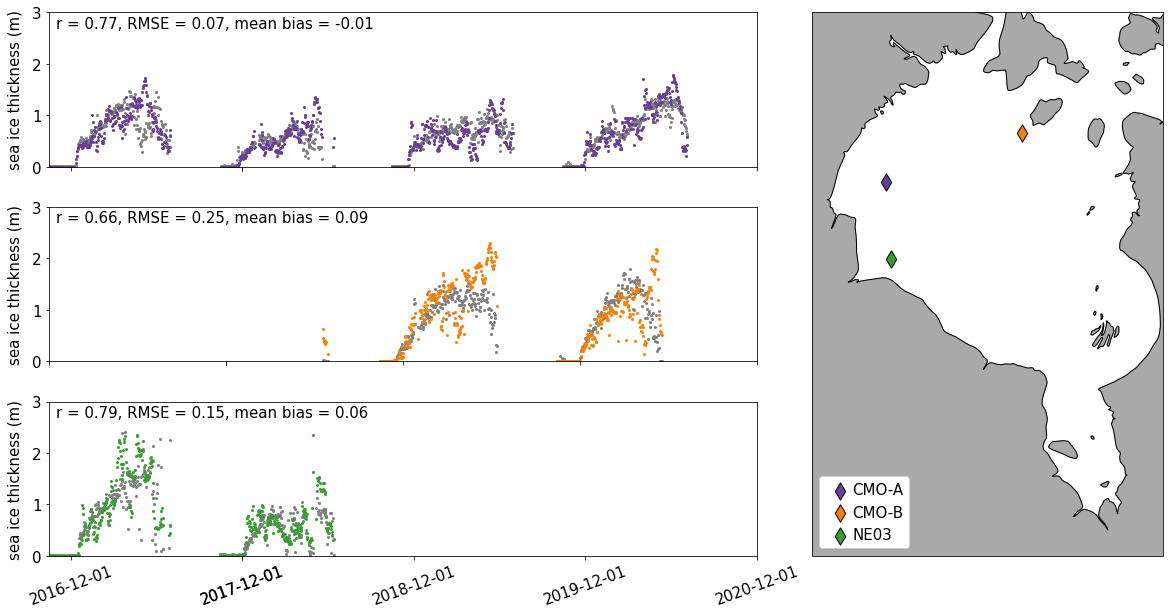

In [210]:
figpath = '/Users/carmennab/Dropbox/Apps/Overleaf/CRiceS_PolarBears_HB/figures/'

fig = plt.figure(figsize=(20,10))
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.26,wspace=0.1,width_ratios=[2,1])
plt.rcParams.update({'font.size': 15})

mooring_names = ['CMO-A','CMO-B','NE03']
colors = ['#6a3d9a','#ff7f00','#33a02c','#1f78b4','#fdbf6f','#b2df8a','#e31a1c','#cab2d6',]
tick_dates = [datetime.date(2016, 12, 1), datetime.date(2017, 12, 1), datetime.date(2017, 12, 1), 
                   datetime.date(2018, 12, 1), datetime.date(2019, 12, 1), datetime.date(2020, 12, 1)]

### plot timeseries
for count,mooring in enumerate(mooring_names):
    ax = fig.add_subplot(spec[count,0])
    mooring_data = all_sits[all_sits['combined name']==mooring].sort_values(['date'])

    dates = mooring_data['date']
    
    sat_sit = mooring_data['CS2_SIT']
    mooring_sit = mooring_data['mooring_sit']

    ax.scatter(dates,mooring_sit,color='grey',s=4)
    ax.scatter(dates,sat_sit,color = colors[count],s=4)

    ax.set_ylim([0,3])

    ax.set_ylabel('sea ice thickness (m)',labelpad=10)
    ax.axhline(0,linestyle = '--',color='k',linewidth=1)

    start = dates.iloc[0]
    end = dates.iloc[-1]
    ax.set_xlim([start,end])
    
    ax.set_xticks(tick_dates)
    if count == 2:
        ax.set_xticklabels(tick_dates,rotation = 20)
    else:
        ax.set_xticklabels([])
    ### calculate stats 
    mask = ~np.isnan(mooring_sit) & ~np.isnan(sat_sit) # mask out cells with nan mooring or nan cs2
    rstats = linregress(mooring_sit[mask],sat_sit[mask]) # correlate valid mooring and cs2 for each grid cell
    r = np.round(rstats.rvalue,2)
    rmse = np.round(np.nanmean(((sat_sit-mooring_sit)**2)),2)
    bias = np.round(np.nanmean(sat_sit-mooring_sit),2)


    ### add stats to plot 
    ax.text(0.01, 0.9, f'r = {r}, RMSE = {rmse}, mean bias = {bias}',ha='left',color='k',
            transform = ax.transAxes)
    
# plot mooring locations
ax1 = fig.add_subplot(spec[:,1],projection=ccrs.NorthPolarStereo(central_longitude=-80))
ax1.add_feature(cartopy.feature.LAND, color='darkgrey',zorder=1)
ax1.add_feature(cartopy.feature.OCEAN, color='white', edgecolor='black')
ax1.set_extent([-92, -77, 50, 65], ccrs.PlateCarree())
ax1.coastlines()
for color,mooring in zip(colors,mooring_names):
    lats = locs[locs['combined name']==mooring]['lat']
    lons = locs[locs['combined name']==mooring]['lon']

    ax1.scatter(lons.iloc[0],lats.iloc[0],transform=ccrs.PlateCarree(),color=color,label=mooring,s=150,marker="d",edgecolors='black')

ax1.legend(loc='lower left',columnspacing=0.3,handletextpad=-0.2, ncol=1,framealpha=1)
# ax1.text(0.2, 0.53, 'Churchill', transform=ax1.transAxes, ha='center', va='center')
# ax1.text(0.5, 0.1, 'James Bay', transform=ax1.transAxes, ha='center', va='center')


plt.savefig(f'{figpath}sit_validation.jpg', bbox_inches = "tight", dpi = 400)